# London Property Sales — Predictive Analytics
## Group Coursework
### City: London, United Kingdom (Developed Economy)

In [1]:
#Importing relevant libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# DATA UNDERSTANDING

In [2]:
#Loading the dataset
df=pd.read_csv('london.csv')

In [3]:
df.head()

,date,area,average_price,code,houses_sold,no_of_crimes
0,1/1/1995,city of london,91449,E09000001,17.0,NaN
1,2/1/1995,city of london,82203,E09000001,7.0,NaN
2,3/1/1995,city of london,79121,E09000001,14.0,NaN
3,4/1/1995,city of london,77101,E09000001,7.0,NaN
4,5/1/1995,city of london,84409,E09000001,10.0,NaN


In [4]:
df.shape

(13549, 6)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13549 entries, 0 to 13548
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           13549 non-null  object 
 1   area           13549 non-null  object 
 2   average_price  13549 non-null  int64  
 3   code           13549 non-null  object 
 4   houses_sold    13455 non-null  float64
 5   no_of_crimes   7439 non-null   float64
dtypes: float64(2), int64(1), object(3)
memory usage: 635.2+ KB


In [6]:
df.describe()

,average_price,houses_sold,no_of_crimes
count,1.354900e+04,13455.000000,7439.000000
mean,2.635197e+05,3893.994129,2158.352063
std,1.876175e+05,12114.402476,902.087742
min,4.072200e+04,2.000000,0.000000
25%,1.323800e+05,247.000000,1623.000000
50%,2.229190e+05,371.000000,2132.000000
75%,3.368430e+05,3146.000000,2582.000000
max,1.463378e+06,132163.000000,7461.000000


# DATA PREPARATION

In [7]:
df["date"] = pd.to_datetime(df["date"])

In [8]:
# Keeping only real London boroughs (drop regional aggregates like 'england', 'south east', 'london', etc.)
regions_to_exclude = ["london", "inner london", "outer london", "north east", "north west",
                       "yorks and the humber", "east midlands", "west midlands",
                       "east of england", "south east", "south west", "england"]
boroughs = df[~df["area"].isin(regions_to_exclude)].copy()

In [9]:
df.columns

Index(['date', 'area', 'average_price', 'code', 'houses_sold', 'no_of_crimes'], dtype='object')

In [10]:
# city of london has too much missing crime data (63%) — drop it too
boroughs = boroughs[boroughs["area"] != "city of london"]

In [11]:
# Drop rows missing no_of_crimes (crime tracking started later; ~24% of rows, mostly pre-2001)
boroughs = boroughs.dropna(subset=["no_of_crimes"])

In [12]:
df.isna().sum()

date                0
area                0
average_price       0
code                0
houses_sold        94
no_of_crimes     6110
dtype: int64

In [13]:
# Fill the few missing houses_sold with the area's median
boroughs['houses_sold'].median()
boroughs['houses_sold'] = boroughs['houses_sold'].fillna(boroughs['houses_sold'].median())

In [14]:
# Time features
boroughs["year"] = boroughs["date"].dt.year
boroughs["month"] = boroughs["date"].dt.month

In [15]:
print(boroughs.shape)
boroughs.head()

(7328, 8)


,date,area,average_price,code,houses_sold,no_of_crimes,year,month
373,2001-01-01,barking and dagenham,82343,E09000002,215.0,1771.0,2001,1
374,2001-02-01,barking and dagenham,83266,E09000002,238.0,1600.0,2001,2
375,2001-03-01,barking and dagenham,84058,E09000002,274.0,1759.0,2001,3
376,2001-04-01,barking and dagenham,83965,E09000002,241.0,1643.0,2001,4
377,2001-05-01,barking and dagenham,85124,E09000002,283.0,1809.0,2001,5


# DATA VISUALIZATION

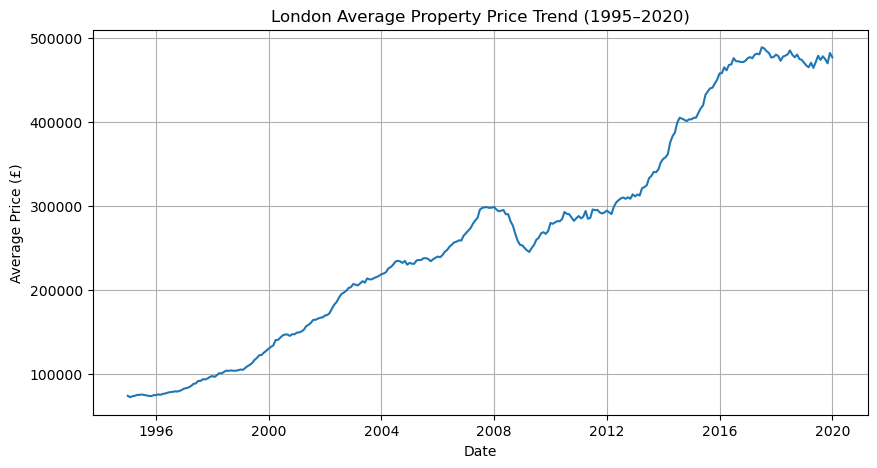

In [16]:
# Overall London price trend (using the 'london' aggregate row, before we filtered it out)
london_city = df[df["area"] == "london"].copy()
london_city["date"] = pd.to_datetime(london_city["date"])

plt.figure(figsize=(10, 5))
plt.plot(london_city["date"], london_city["average_price"])
plt.title("London Average Property Price Trend (1995–2020)")
plt.xlabel("Date")
plt.ylabel("Average Price (£)")
plt.grid(True)
plt.show()

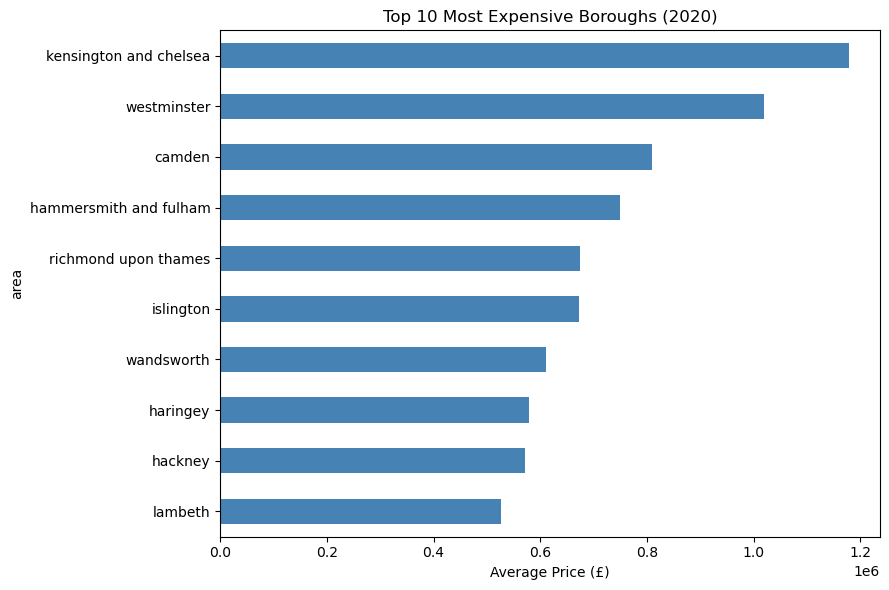

In [17]:
# Top 10 most expensive boroughs (latest year available)
latest_year = boroughs["year"].max()
top_boroughs = (boroughs[boroughs["year"] == latest_year]
                 .groupby("area")["average_price"].mean()
                 .sort_values(ascending=False).head(10))

plt.figure(figsize=(9, 6))
top_boroughs.plot(kind="barh", color="steelblue")
plt.title(f"Top 10 Most Expensive Boroughs ({latest_year})")
plt.xlabel("Average Price (£)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

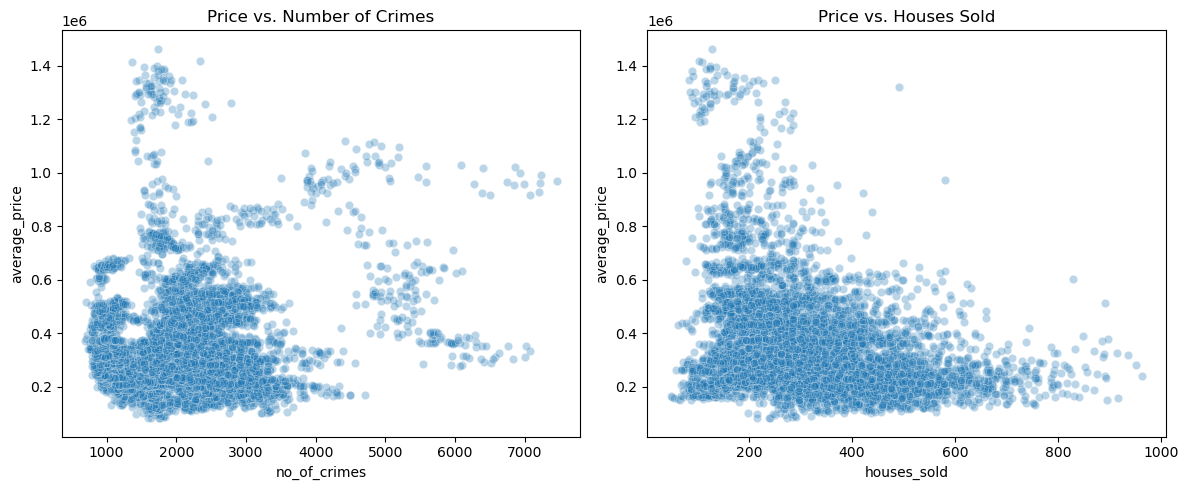

In [18]:
# Price vs crime, price vs houses sold
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.scatterplot(data=boroughs, x="no_of_crimes", y="average_price", alpha=0.3, ax=axes[0])
axes[0].set_title("Price vs. Number of Crimes")

sns.scatterplot(data=boroughs, x="houses_sold", y="average_price", alpha=0.3, ax=axes[1])
axes[1].set_title("Price vs. Houses Sold")
plt.tight_layout()
plt.show()

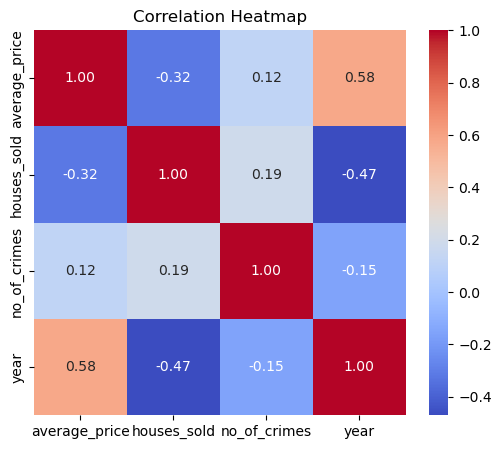

In [19]:
#Correlation heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(boroughs[["average_price", "houses_sold", "no_of_crimes", "year"]].corr(),
            annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

## ENCODING

In [20]:
# Encode area (borough) as dummies
df_reg = pd.get_dummies(boroughs, columns=["area"], drop_first=True)

## Trainung and Testing the Data

In [21]:
#Defining target and features
drop_cols = ['average_price', "date", "code"]
x = df_reg.drop(columns=drop_cols)
y = df_reg['average_price']

In [22]:
#Splitting the data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

## Feature Scaling

In [23]:
scaler = StandardScaler()
x_train_sc = scaler.fit_transform(x_train)
x_test_sc = scaler.transform(x_test)

## Building the model

In [24]:
model=LinearRegression()

In [25]:
model.fit(x_train_sc,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [26]:
#Making predictions
y_pred=model.predict(x_test_sc)
print(y_pred[:10])

[428393.42136109 369909.82159599 432339.64329695 336075.8058273
 198547.25302729 238679.34999768 117799.34010681 261127.45123435
 192074.78802602 136357.23771597]


In [27]:
#Model interceot
model.intercept_

np.float64(350484.5614124886)

In [28]:
#Model coefficient
model.coef_

array([ 16910.97454909, -12299.90370278, 116678.42751251,   4598.65491182,
        26825.23139578,   2204.64456889,  24802.2300873 ,  14793.42931467,
        68098.47354094,   6733.77502533,  22894.56914798,  10687.49110095,
         9937.18401979,  29593.92521873,  59999.19063171,  29649.15634941,
        20774.17335338,   7190.77734726,  13942.54142965,  15287.00817164,
        45786.42212097, 122039.81519846,  22646.77196799,  25928.57480345,
        11474.43716084,  23415.73283691,   9324.66242431,  14055.65921658,
        42221.19216548,  25379.63518131,   8506.44763828,  20433.08786397,
        13223.38339991,  33096.46945052,  87155.0718054 ])

In [29]:
#Checking for errors
residuals=y_test-y_pred
residuals

3747   -60197.421361
2370    -6338.821596
1454    23085.356703
7948    -8509.805827
5259    37302.746973
            ...     
430     72986.143610
5598   -88871.557726
6167     4791.532861
1044    39380.117076
2667    35251.834023
Name: average_price, Length: 1466, dtype: float64

In [30]:
results=pd.DataFrame({'Actual':y_test,
                      'Predicted':y_pred})
results

,Actual,Predicted
3747,368196,428393.421361
2370,363571,369909.821596
1454,455425,432339.643297
7948,327566,336075.805827
5259,235850,198547.253027
...,...,...
430,164179,91192.856390
5598,339509,428380.557726
6167,275061,270269.467139
1044,196532,157151.882924


In [31]:
results['Residual']=residuals
results.head()

,Actual,Predicted,Residual
3747,368196,428393.421361,-60197.421361
2370,363571,369909.821596,-6338.821596
1454,455425,432339.643297,23085.356703
7948,327566,336075.805827,-8509.805827
5259,235850,198547.253027,37302.746973


In [32]:
#Checking for r2 score
r2=r2_score(y_test,y_pred)
r2

0.8847894786922159

In [34]:
print("=== Linear Regression ===")
print(f"R²:   {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):,.0f}")
print(f"MAE:  {mean_absolute_error(y_test, y_pred):,.0f}")

=== Linear Regression ===
R²:   0.8848
RMSE: 64,508
MAE:  46,394


# RIDGE REGRESSION

In [37]:
#Ridge Regression (regularization — helps with the many correlated borough dummies)
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=10)
ridge.fit(x_train_sc, y_train)
y_pred_ridge = ridge.predict(x_test_sc)

print("=== Ridge Regression ===")
print(f"R²:   {r2_score(y_test, y_pred_ridge):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_ridge)):,.0f}")
print(f"MAE:  {mean_absolute_error(y_test, y_pred_ridge):,.0f}")

=== Ridge Regression ===
R²:   0.8849
RMSE: 64,480
MAE:  46,277


# TIME SERIES
## SMA( 3 Months)

In [38]:
# Use the city-wide 'london' series, monthly (already monthly, no need to resample)
ts = london_city.set_index("date")["average_price"].sort_index()

train_size = int(len(ts) * 0.8)
train_series = ts.iloc[:train_size]
test_series = ts.iloc[train_size:]

In [39]:
#Simple Moving Average (recursive)
window = 3
history = list(train_series)
forecast_sma = []
for _ in range(len(test_series)):
    next_val = np.mean(history[-window:])
    forecast_sma.append(next_val)
    history.append(next_val)

mae_sma = mean_absolute_error(test_series, forecast_sma)
rmse_sma = np.sqrt(mean_squared_error(test_series, forecast_sma))
mape_sma = np.mean(np.abs((test_series - forecast_sma) / test_series)) * 100
print(f"SMA — MAE: {mae_sma:,.0f}, RMSE: {rmse_sma:,.0f}, MAPE: {mape_sma:.2f}%")

SMA — MAE: 62,606, RMSE: 66,289, MAPE: 13.27%


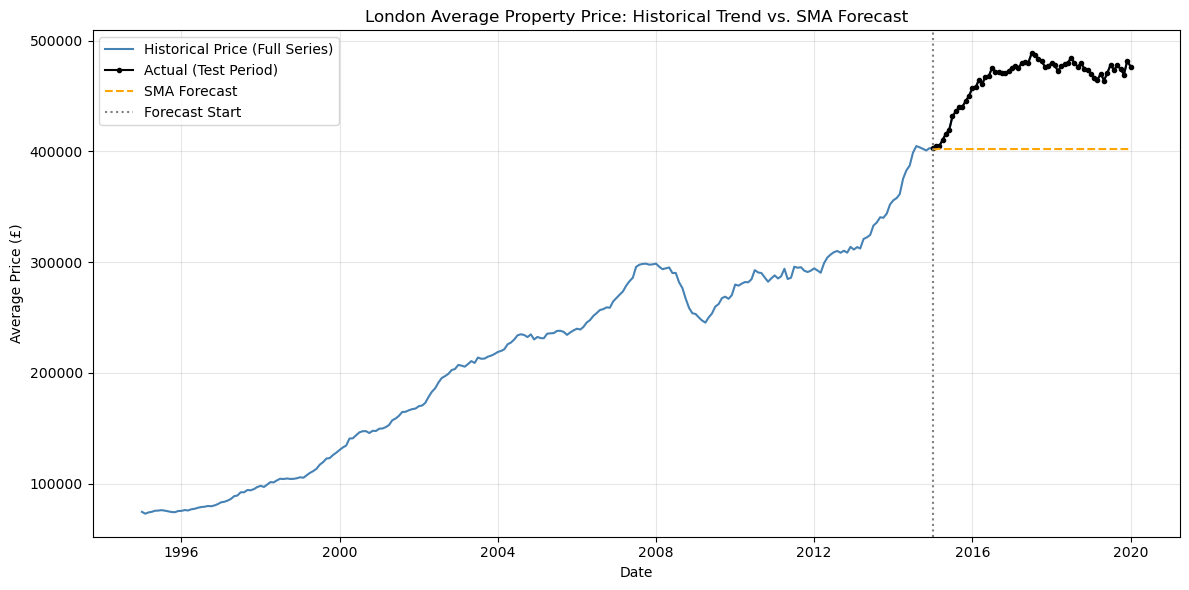

In [40]:
plt.figure(figsize=(12, 6))

plt.plot(ts.index, ts.values, label="Historical Price (Full Series)", color="steelblue")
plt.plot(test_series.index, test_series.values, label="Actual (Test Period)",
          color="black", marker="o", markersize=3)
plt.plot(test_series.index, forecast_sma, label="SMA Forecast",
          color="orange", linestyle="--")
plt.axvline(x=test_series.index[0], color="gray", linestyle=":", label="Forecast Start")

plt.title("London Average Property Price: Historical Trend vs. SMA Forecast")
plt.xlabel("Date")
plt.ylabel("Average Price (£)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Holt Exponential Smoothing

In [51]:
#Holt's Exponential Smoothing
from statsmodels.tsa.holtwinters import ExponentialSmoothing

holt_model = ExponentialSmoothing(train_series, trend="add", seasonal=None,
                                    initialization_method="estimated").fit()
forecast_holt = holt_model.forecast(len(test_series))

mae_holt = mean_absolute_error(test_series, forecast_holt)
rmse_holt = np.sqrt(mean_squared_error(test_series, forecast_holt))
mape_holt = np.mean(np.abs((test_series - forecast_holt) / test_series)) * 100
print(f"Holt's — MAE: {mae_holt:,.0f}, RMSE: {rmse_holt:,.0f}, MAPE: {mape_holt:.2f}%")

Holt's — MAE: 23,841, RMSE: 29,377, MAPE: 5.08%


C:\Users\Hi\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


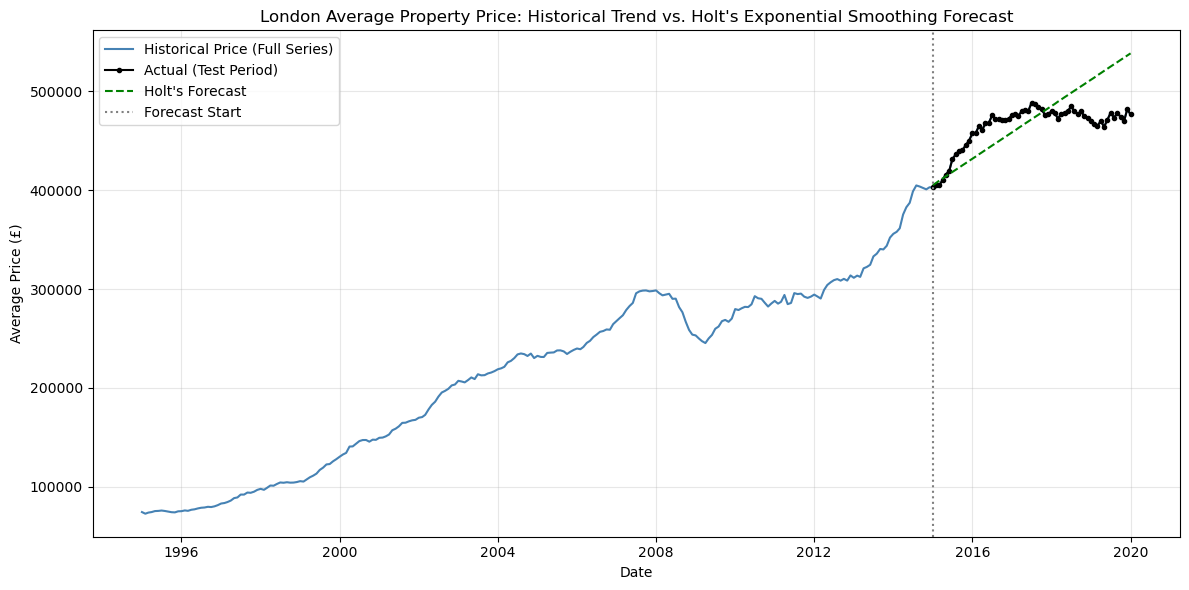

In [53]:
plt.figure(figsize=(12, 6))

plt.plot(ts.index, ts.values, label="Historical Price (Full Series)", color="steelblue")
plt.plot(test_series.index, test_series.values, label="Actual (Test Period)",
          color="black", marker="o", markersize=3)
plt.plot(test_series.index, forecast_holt, label="Holt's Forecast",
          color="green", linestyle="--")
plt.axvline(x=test_series.index[0], color="gray", linestyle=":", label="Forecast Start")

plt.title("London Average Property Price: Historical Trend vs. Holt's Exponential Smoothing Forecast")
plt.xlabel("Date")
plt.ylabel("Average Price (£)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Comparing Holt and SMA

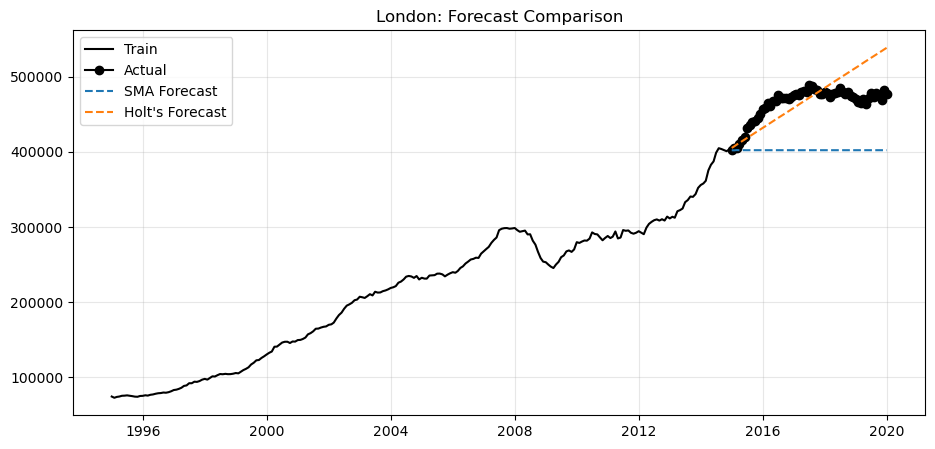

In [52]:
plt.figure(figsize=(11, 5))
plt.plot(train_series.index, train_series, label="Train", color="black")
plt.plot(test_series.index, test_series, label="Actual", marker="o", color="black")
plt.plot(test_series.index, forecast_sma, label="SMA Forecast", linestyle="--")
plt.plot(test_series.index, forecast_holt, label="Holt's Forecast", linestyle="--")
plt.title("London: Forecast Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Recommendations for Miss Akoto — ED Happiness Estates
### Focus Market: London, United Kingdom (Advanced/Developed Economy)

Based on our predictive analysis of the London residential real estate market, the following five 
recommendations are offered to guide deployment of investment capital toward ultra-modern 
brutalist developments for rental and sale.

### 1. Treat London as a stable, high-confidence anchor investment
Both Linear Regression (R² = 0.8848) and Ridge Regression (R² = 0.8849) explain roughly 88% of 
the variance in London property prices — a strong result reflecting London's maturity as a 
well-documented, data-rich market. The near-identical performance of Linear and Ridge also 
indicates the model is stable and not overly sensitive to multicollinearity among the borough 
indicators. This predictability supports allocating a larger, longer-term share of capital to 
London relative to less-established markets such as Accra.

### 2. Anchor development decisions on borough-level price drivers, not headline city averages
Our regression coefficients show substantial variation in price premiums across boroughs, with 
some (e.g., the highest-coefficient boroughs in our model) commanding well over £100,000 more 
than the baseline borough, holding other factors constant. Combined with our correlation analysis 
showing house sales volume and crime levels as relevant secondary factors, ED Happiness Estates 
should prioritize high-premium boroughs identified in our feature analysis over cheaper 
boroughs with weaker underlying demand fundamentals.

### 3. Use Holt's Exponential Smoothing, not simple averaging, for investment timing
Our two time-series models produced very different reliability: SMA returned a MAPE of 13.27% 
(MAE £62,606, RMSE £66,289), while Holt's Exponential Smoothing achieved a substantially better 
MAPE of 5.08% (MAE £23,841, RMSE £29,377). This confirms London's price trend is better captured 
by a model that weights recent momentum and trend direction (Holt's) rather than a flat rolling 
average (SMA), which lags behind sustained price growth. We recommend using Holt's forecasts as 
the basis for phased capital deployment timing.

### 4. Position London for premium rental income, not fast resale
Given London's status as a global financial hub with consistently high demand, historically tight 
housing supply, and Holt's model showing continued upward price momentum (MAPE 5.08%, indicating 
high forecast confidence), we recommend ED Happiness Estates lead with a rental-focused strategy 
in London — in contrast to the sales-led approach better suited to Accra's more nascent, 
price-sensitive market — to capture recurring yield from long-term tenant demand.


---
*Note: Recommendations are supported by regression (Linear R² = 0.8848, Ridge R² = 0.8849) and 
time-series (SMA MAPE = 13.27%, Holt's MAPE = 5.08%) model outputs presented in the Results 
section above.*